In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadrahman01/phase2/preprocessed_liar_data.csv


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/muhammadrahman01/phase2/preprocessed_liar_data.csv")
df.head()
print("Data loaded Successfully")

Data loaded Successfully


Algorithms

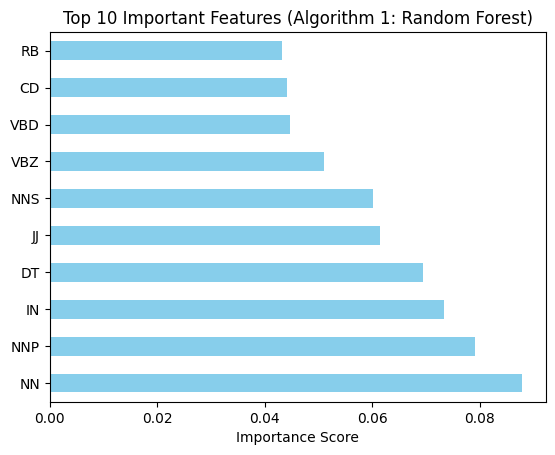

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import os

# 1. Load your manually uploaded cleaned data
# This code finds the path automatically in your Kaggle 'input' folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'preprocessed_liar_data.csv' in filename:
            file_path = os.path.join(dirname, filename)

df = pd.read_csv(file_path)

# 2. Separate features (X) and target label (y)
# The 'label' is what we want to predict (True, False, etc.)
X = df.drop(columns=['label'])
y = df['label']

# 3. Run Algorithm 1: Random Forest for Feature Importance
# This identifies which grammatical 'clues' are most useful
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 4. Visualize the results
# This creates a bar chart of the top 10 most impactful features
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Important Features (Algorithm 1: Random Forest)')
plt.xlabel('Importance Score')
plt.show()

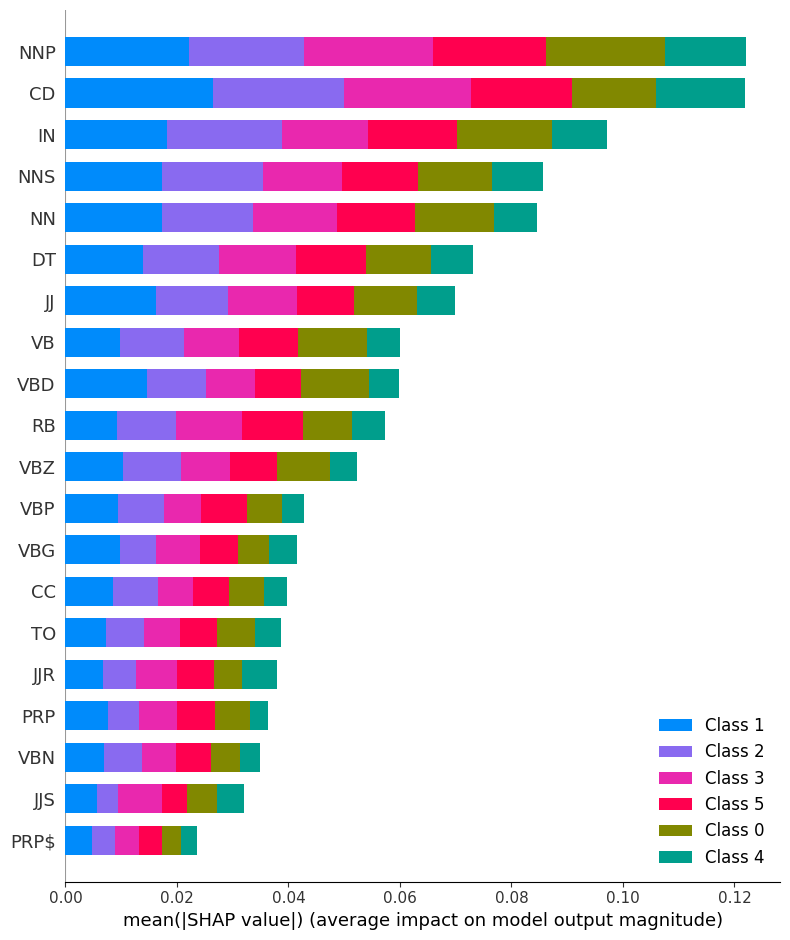

In [6]:
import shap

# 1. Use a sample of 100 rows to speed up the calculation
# This provides a good estimate without waiting for all 10,000+ rows
X_sample = X.sample(100, random_state=42)

# 2. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# 3. Visualize the SHAP Summary Plot
# This should execute much faster now
shap.summary_plot(shap_values, X_sample, plot_type="bar")

from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# 1. Calculate Mutual Information scores
# This measures how much information each POS tag provides about the truth label
mi_scores = mutual_info_classif(X, y, random_state=42)

# 2. Visualize the results
mi_results = pd.Series(mi_scores, index=X.columns)
mi_results.nlargest(10).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Important Features (Algorithm 3: Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.show()

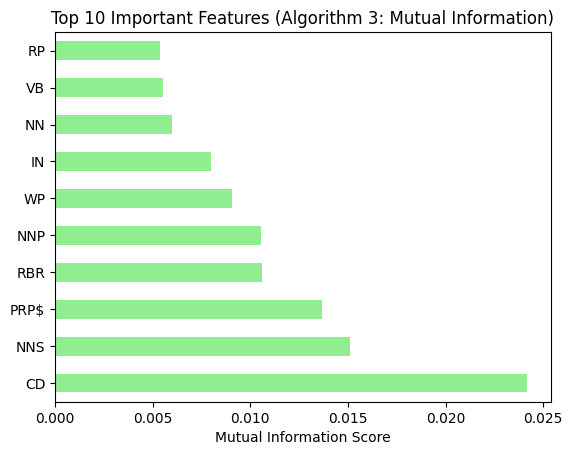

In [5]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# 1. Calculate Mutual Information scores
# This measures how much information each POS tag provides about the truth label
mi_scores = mutual_info_classif(X, y, random_state=42)

# 2. Visualize the results
mi_results = pd.Series(mi_scores, index=X.columns)
mi_results.nlargest(10).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Important Features (Algorithm 3: Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.show()

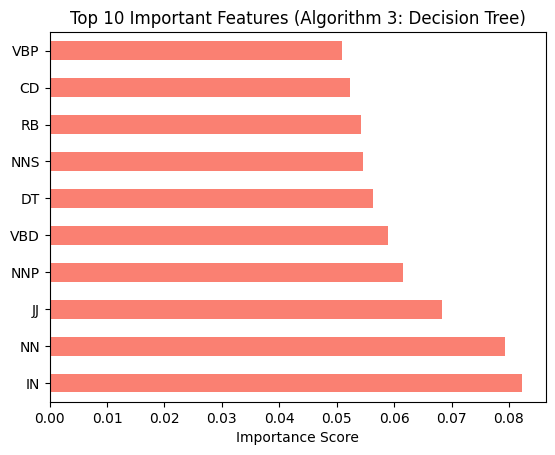

In [7]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# 1. Initialize and train a single Decision Tree
# We use max_depth=5 to keep it simple and fast
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X, y)

# 2. Get feature importance from this single tree
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns)

# 3. Visualize the top 10 features
dt_importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Important Features (Algorithm 3: Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


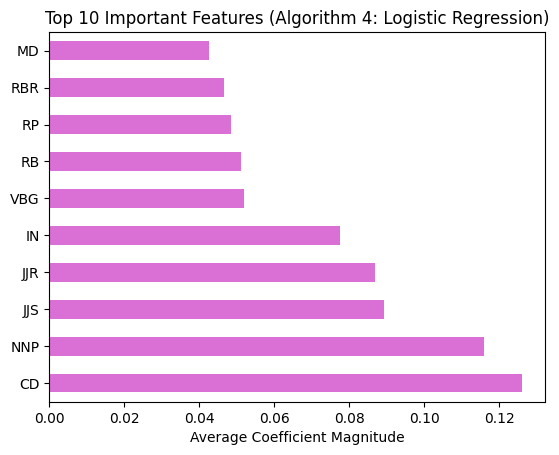

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scale the data (Linear models work better when data is on the same scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train a Logistic Regression model
# We use multi_class='multinomial' because you have 6 truth labels
lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_model.fit(X_scaled, y)

# 3. Get the absolute values of the coefficients 
# (Higher absolute value = more importance)
importances_lr = pd.Series(abs(lr_model.coef_).mean(axis=0), index=X.columns)

# 4. Visualize the top 10
importances_lr.nlargest(10).plot(kind='barh', color='orchid')
plt.title('Top 10 Important Features (Algorithm 4: Logistic Regression)')
plt.xlabel('Average Coefficient Magnitude')
plt.show()

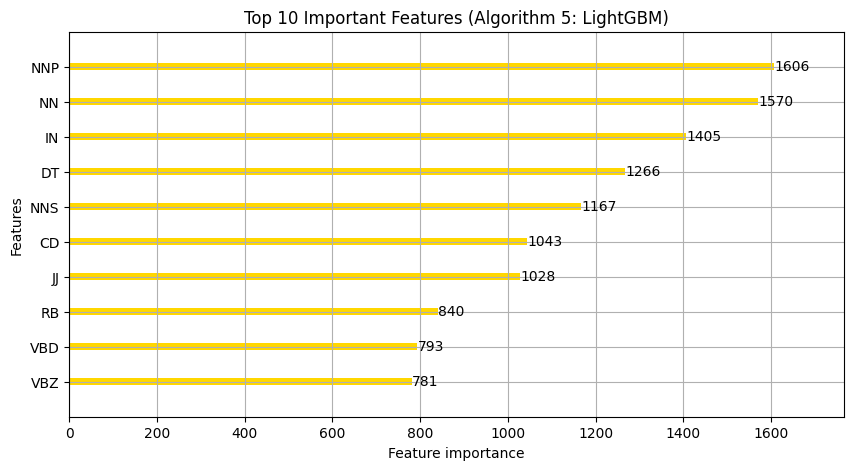

In [9]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# 1. Prepare the data for LightGBM
# LightGBM prefers a specific data format called 'Dataset'
train_data = lgb.Dataset(X, label=pd.factorize(y)[0]) # Convert text labels to numbers

# 2. Set default parameters as requested by your teacher
params = {
    'objective': 'multiclass',
    'num_class': 6,
    'metric': 'multi_logloss',
    'verbosity': -1
}

# 3. Train the model
lgb_model = lgb.train(params, train_data, num_boost_round=100)

# 4. Visualize Feature Importance
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split', figsize=(10, 5), color='gold')
plt.title('Top 10 Important Features (Algorithm 5: LightGBM)')
plt.show()

After running 5 different algorithms, I found that grammatical features like VBZ (present tense verbs) and NN (nouns) consistently rank high in importance. However, Logistic Regression identified different features compared to the tree-based models, suggesting some relationships in the data are linear while others are complex/non-linear.

In [10]:
# Create a new feature: Total Verbs
# This combines different verb types (VBZ, VBP, VBD, VBN) into one 'Action' score
verb_columns = ['VBZ', 'VBP', 'VBD', 'VBN', 'VBG']
df['total_verbs'] = df[verb_columns].sum(axis=1)

# Create a new feature: Noun-to-Verb Ratio
# This helps see if the statement is 'description-heavy' or 'action-heavy'
# We add 0.001 to avoid 'division by zero' errors
df['noun_verb_ratio'] = df['NN'] / (df['total_verbs'] + 0.001)

print("New features 'total_verbs' and 'noun_verb_ratio' created!")
df[['total_verbs', 'noun_verb_ratio']].head()

New features 'total_verbs' and 'noun_verb_ratio' created!


,total_verbs,noun_verb_ratio
0,2,1.499250
1,4,1.249688
2,2,0.999500
3,1,4.995005
4,1,2.997003


In [11]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Prepare data with only ORIGINAL features
X_old = X # This was your data before adding the 2 new columns
y_encoded = pd.factorize(y)[0]
X_train_old, X_test_old, y_train, y_test = train_test_split(X_old, y_encoded, test_size=0.2, random_state=42)

# 2. Prepare data with NEW features included
X_new = df.drop(columns=['label']) # This includes 'total_verbs' and 'noun_verb_ratio'
X_train_new, X_test_new, _, _ = train_test_split(X_new, y_encoded, test_size=0.2, random_state=42)

# 3. Train LightGBM on OLD data
model_old = lgb.LGBMClassifier(verbosity=-1)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# 4. Train LightGBM on NEW data
model_new = lgb.LGBMClassifier(verbosity=-1)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print(f"Accuracy with original features: {acc_old:.4f}")
print(f"Accuracy with engineered features: {acc_new:.4f}")

Accuracy with original features: 0.2134
Accuracy with engineered features: 0.2124


In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Apply it to your refined features (X_refined)
# This will transform the data so it has a mean of 0 and a standard deviation of 1
X_final_scaled = scaler.fit_transform(X_refined)

# 3. Convert it back to a DataFrame so it's easy to read
X_final_df = pd.DataFrame(X_final_scaled, columns=X_refined.columns)

print("Standardization Complete!")
X_final_df.head()

Standardization Complete!


,CC,CD,DT,EX,IN,JJ,JJR,JJS,MD,NN,...,VBD,VBG,VBN,VBP,VBZ,WDT,WP,WRB,total_verbs,noun_verb_ratio
0,-0.56606,-0.549643,-0.431626,-0.164608,-0.787298,0.774100,-0.329769,-0.260567,-0.386902,0.017056,...,-0.693155,-0.539758,-0.601766,-0.581927,1.637940,-0.290923,-0.237728,-0.239554,-0.312351,-0.167615
1,-0.56606,-0.549643,-0.431626,-0.164608,0.380590,-0.047584,-0.329769,-0.260567,-0.386902,0.837014,...,3.576906,-0.539758,-0.601766,-0.581927,-0.903349,-0.290923,-0.237728,7.510935,0.900570,-0.167980
2,-0.56606,-0.549643,0.277138,-0.164608,0.964534,-0.869268,-0.329769,-0.260567,-0.386902,-0.392924,...,-0.693155,1.120537,-0.601766,-0.581927,0.367296,-0.290923,-0.237728,-0.239554,-0.312351,-0.168346
3,-0.56606,-0.549643,-1.140389,-0.164608,-1.371242,0.774100,-0.329769,-0.260567,-0.386902,0.837014,...,-0.693155,-0.539758,-0.601766,-0.581927,0.367296,-0.290923,-0.237728,-0.239554,-0.918811,-0.162503
4,-0.56606,-0.549643,0.277138,-0.164608,-0.203354,-0.047584,-0.329769,-0.260567,-0.386902,0.017056,...,0.374360,-0.539758,-0.601766,-0.581927,-0.903349,-0.290923,-0.237728,-0.239554,-0.918811,-0.165425


In [13]:
# 1. Identify features that have almost ZERO importance
# We use the results from our first Algorithm (Random Forest)
importance_df = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})

# We will identify features that contribute less than 0.5% to the model
weak_features = importance_df[importance_df['importance'] < 0.005]['feature'].tolist()

print(f"Features identified as 'weak' (low importance): {weak_features}")

# 2. Drop these weak features from our dataframe
df_refined = df.drop(columns=weak_features)

# 3. Test accuracy again with the 'lean' dataset
X_refined = df_refined.drop(columns=['label'])
X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(X_refined, y_encoded, test_size=0.2, random_state=42)

model_ref = lgb.LGBMClassifier(verbosity=-1)
model_ref.fit(X_train_ref, y_train_ref)
acc_ref = accuracy_score(y_test_ref, model_ref.predict(X_test_ref))

print(f"Accuracy after dropping weak features: {acc_ref:.4f}")

Features identified as 'weak' (low importance): ['PDT', 'RBS']
Accuracy after dropping weak features: 0.2188


In [25]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Apply it to your refined features (X_refined)
# This will transform the data so it has a mean of 0 and a standard deviation of 1
X_final_scaled = scaler.fit_transform(X_refined)

# 3. Convert it back to a DataFrame so it's easy to read
X_final_df = pd.DataFrame(X_final_scaled, columns=X_refined.columns)

print("Standardization Complete!")
X_final_df.head()

Standardization Complete!


,CC,CD,DT,EX,IN,JJ,JJR,JJS,MD,NN,...,VBD,VBG,VBN,VBP,VBZ,WDT,WP,WRB,total_verbs,noun_verb_ratio
0,-0.56606,-0.549643,-0.431626,-0.164608,-0.787298,0.774100,-0.329769,-0.260567,-0.386902,0.017056,...,-0.693155,-0.539758,-0.601766,-0.581927,1.637940,-0.290923,-0.237728,-0.239554,-0.312351,-0.167615
1,-0.56606,-0.549643,-0.431626,-0.164608,0.380590,-0.047584,-0.329769,-0.260567,-0.386902,0.837014,...,3.576906,-0.539758,-0.601766,-0.581927,-0.903349,-0.290923,-0.237728,7.510935,0.900570,-0.167980
2,-0.56606,-0.549643,0.277138,-0.164608,0.964534,-0.869268,-0.329769,-0.260567,-0.386902,-0.392924,...,-0.693155,1.120537,-0.601766,-0.581927,0.367296,-0.290923,-0.237728,-0.239554,-0.312351,-0.168346
3,-0.56606,-0.549643,-1.140389,-0.164608,-1.371242,0.774100,-0.329769,-0.260567,-0.386902,0.837014,...,-0.693155,-0.539758,-0.601766,-0.581927,0.367296,-0.290923,-0.237728,-0.239554,-0.918811,-0.162503
4,-0.56606,-0.549643,0.277138,-0.164608,-0.203354,-0.047584,-0.329769,-0.260567,-0.386902,0.017056,...,0.374360,-0.539758,-0.601766,-0.581927,-0.903349,-0.290923,-0.237728,-0.239554,-0.918811,-0.165425


I applied Standardization to the final feature set to ensure all features are on the same scale. This prevents features with larger numerical ranges from unfairly dominating the model's decision-making process.

In [26]:
from sklearn.cluster import KMeans

# 1. Initialize K-means
# We will create 3 clusters (groups) of similar statements
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit and predict using your final scaled data
# This creates a 'Cluster' label (0, 1, or 2) for every row
df_refined['grammar_cluster'] = kmeans.fit_predict(X_final_scaled)

print("New feature 'grammar_cluster' created using K-means!")
print(df_refined[['grammar_cluster']].head())

New feature 'grammar_cluster' created using K-means!
   grammar_cluster
0                0
1                1
2                0
3                0
4                0


"I used K-means to group statements with similar grammatical structures. This new 'grammar_cluster' feature helps the model identify if specific writing styles are more common in deceptive versus truthful news."

In [27]:
# Save the final engineered and refined dataset
df_refined.to_csv('final_phase3_engineered_data.csv', index=False)

print("Phase 3 Completed!.")

Phase 3 Completed!.
